# Non-Monotonic and Pseudo-Nonmonotonic Effects in Quantitative Bipolar Argumentation Graphs
This notebook gives an overview of nonmonotonic and pseudo-nonmonotonic effects in Quantitative Bipolar Argumentation Graphs (QBAGs).
We provide examples for *QE*, *DFQuAD*, *Squared DFQuAD*, *Euler-based*, and *Euler-based Top* semantics.

Let us first install and import some dependencies, and implement some utils.

In [1]:
%%capture
!apt install libgraphviz-dev
!pip install pygraphviz
!pip install 'QBAF-Py[Visualizer] @ git+https://github.com/TimKam/Quantitative-Bipolar-Argumentation.git'

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from qbaf_visualizer.Visualizer import *
from qbaf_ctrbs.removal import *
from qbaf_ctrbs.intrinsic_removal import *
from qbaf_ctrbs.shapley import *
from qbaf_ctrbs.gradient import *

import uncertainpy.gradual as grad

The helper functions below let us plot the final strengths of one or two topic arguments, dependent on the initial strength of a contributor.

In [3]:
def func(contributor_strength, contributor, qbaf, topic):
        initial_strengths = []
        argument_list = list(qbaf.arguments)
        for arg in argument_list:
            if arg == contributor:
                initial_strengths.append(contributor_strength)
            else:
                initial_strengths.append(qbaf.initial_strength(arg))
        qbaf_changed = QBAFramework(argument_list, initial_strengths,
                                    qbaf.attack_relations.relations,
                                    qbaf.support_relations.relations,
                                    semantics=qbaf.semantics)
        return qbaf_changed.final_strength(topic)

def plot_example(qbaf, pseudo=False):
    ises = []
    fsas = []
    fsfs = []
    for ise in range(10, 990):
        fise = ise / 1000
        ises.append(fise)
        fsas.append(abs(func(fise, 'x', qbaf, 't')))
        if pseudo:
          fsfs.append(abs(func(fise, 'x', qbaf, 't\'')))
    plt.plot(np.array(ises), np.array(fsas), color='black')
    if pseudo:
      plt.plot(np.array(ises), np.array(fsfs), color='black', linestyle='--')
    plt.xlabel("Initial strength of x")
    if pseudo:
      plt.ylabel("Final strength of t, respectively t'")
      plt.legend(["Final strength of t, given initial strength of x", "Final strength of t', given initial strength of x"], loc="lower right")
    else:
      plt.ylabel("Final strength of t")
    plt.savefig("my_plot.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    return plt

## Nonmonotonic and Pseudo-Nonmonotonic Effects

Consider a QBAG with _topic_ arguments $t$, $t'$ and _contributor_ $x$.

**Non-monotonic effects** describe that by changing the initial strength of $x$, we can turn $x$'s gradient-based contribution to the final strength of $t$ from positive to negative, or vice versa.

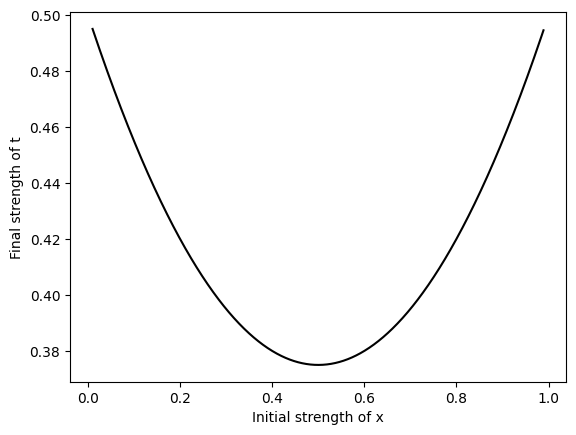

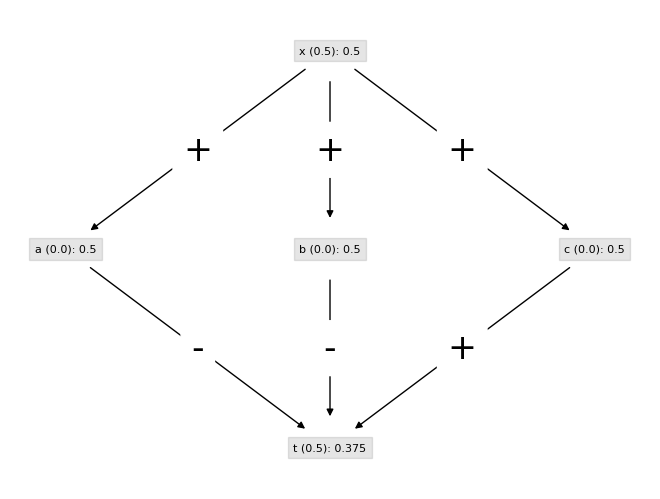

In [4]:
args = ['t', 'a', 'b', 'c', 'x']
initial_strengths = [0.5, 0, 0, 0, 0.5]
atts = [('a', 't'), ('b', 't')]
supps = [('x', 'a'), ('x', 'b'), ('x', 'c'), ('c', 't')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

plot_example(qbaf)
visualize(qbaf, with_fs=True, round_to=6)

Non-monotonic effects make it more difficult to reason about the effect of changes to QBAFs with respect to a specific topic argument, as affecting the final or initial strengths of a contributor monotonically may lead to first increasing and then decreasing the final strength of the topic -- accordingly, an agent may struggle to consistently argue for or against a topic.

**Pseudo-nonmonotonic effects** describe that by changing the initial strength of $x$, we can turn the gradient-based contribution of $x$ to $t$ from greater than the gradient-based contribution of $x$ to $t'$ to smaller than the gradient-based contribution of $x$ to $t'$, or vice versa.
Assuming that an argument without attackers and supporters retains its initial strength as its final strength, non-monotonic effects trivially bring pseudo-nonmonotonic effects with them.

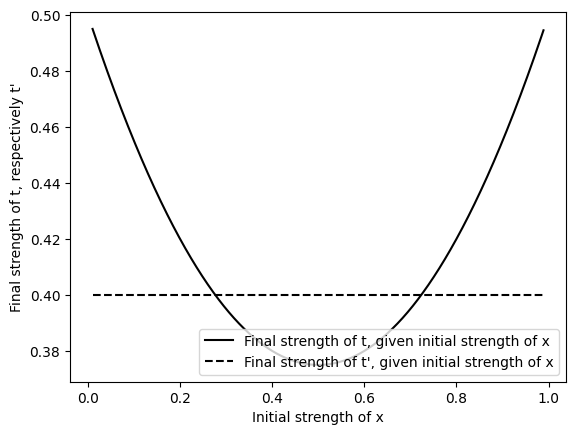

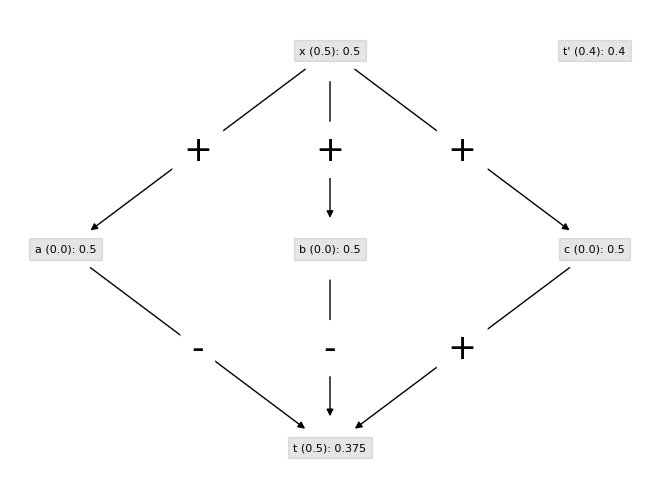

In [5]:
args = ['t', 't\'', 'a', 'b', 'c', 'x']
initial_strengths = [0.5, 0.4, 0, 0, 0, 0.5]
atts = [('a', 't'), ('b', 't')]
supps = [('x', 'a'), ('x', 'b'), ('x', 'c'), ('c', 't')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

However, pseudo-nonmonotonic effects can also occur in absence of nonmonotonic effects.

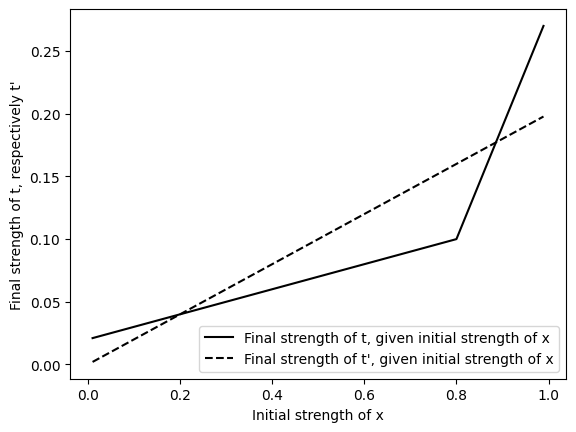

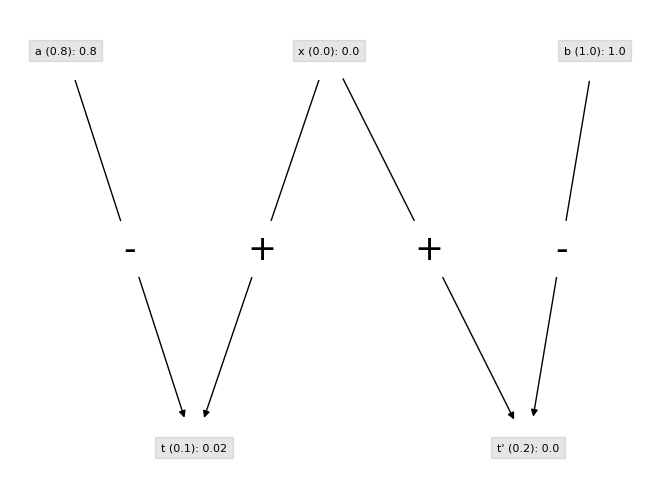

In [6]:
args = ['t', 't\'', 'a', 'b', 'x']
initial_strengths = [0.1, 0.2, 0.8, 1.0, 0.0]
atts = [('a', 't'), ('b', 't\'')]
supps = [('x', 't'), ('x', 't\'')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

Pseudo-nonmonotonic effects make it more difficult to reason about the ranking of topic arguments.
E.g., assume an agent wants to argue that $t$ is stronger than $t'$.
Given pseudo-nonmonotonic effects, the agent cannot safely assume that supporting an argument that affects $t$'s final strengths more (positively) strongly than $t'$'s will have the long-term desired affect of promoting $t$ over $t'$ as the argumentation dialogue continues.

## Existence of Nonmonotonic Effects

### Bipolar Graphs

Nonmonotonic effects exist in acyclic bipolar graphs given all five semantics.

#### QE Semantics

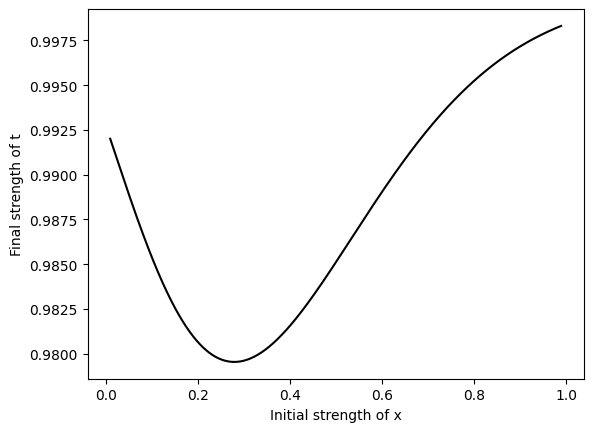

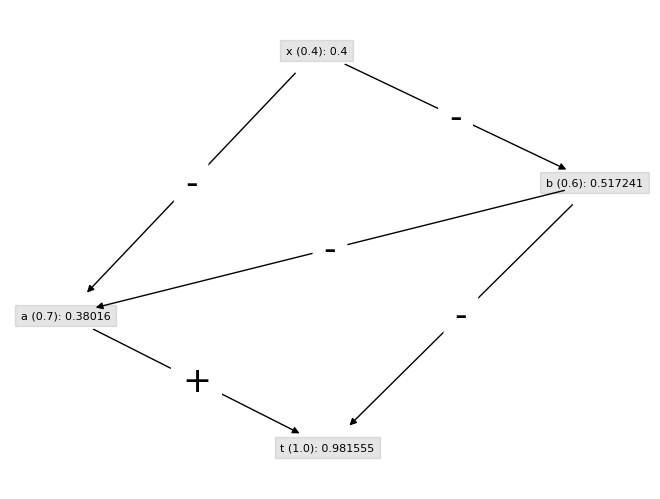

In [7]:
args = ['t', 'a', 'b', 'x']
initial_strengths = [1, 0.7, 0.6, 0.4]
atts = [('b', 'a'), ('b', 't'), ('x', 'a'),  ('x', 'b')]
supps = [('a', 't')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")

plot_example(qbaf)
visualize(qbaf, with_fs=True, round_to=6)


#### DFQuAD Semantics

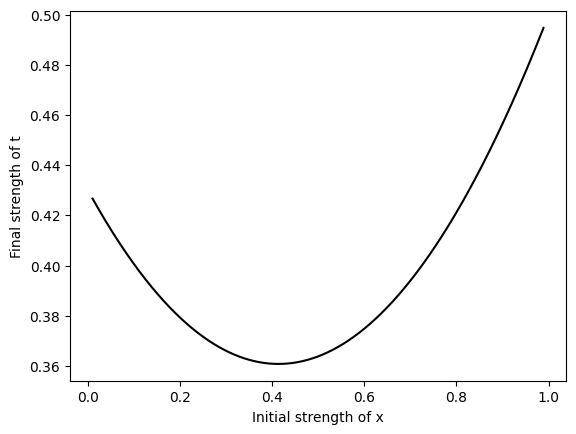

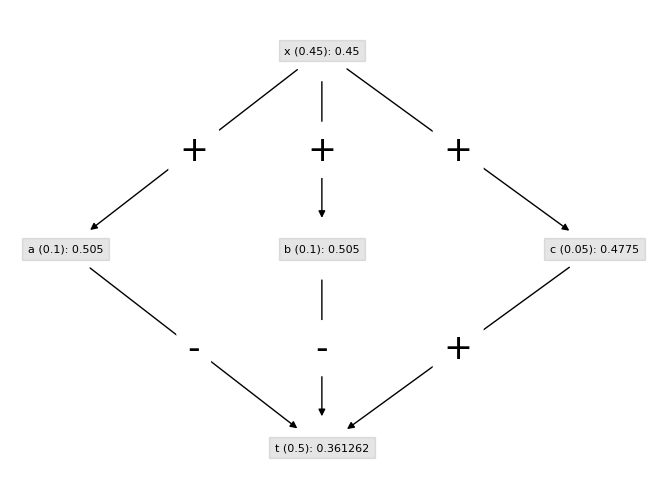

In [8]:
args = ['t', 'a', 'b', 'c', 'x']
initial_strengths = [0.5, 0.1, 0.1, 0.05, 0.45]
atts = [('a', 't'), ('b', 't')]
supps = [('c', 't'), ('x', 'a'), ('x', 'b'), ('x', 'c')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

plot_example(qbaf)
visualize(qbaf, with_fs=True, round_to=6)

#### Squared DFQuAD Semantics

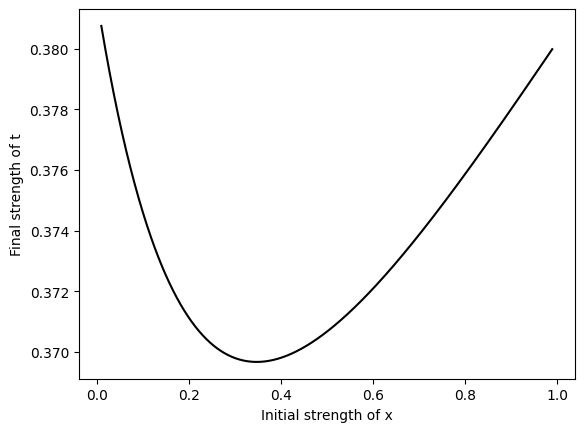

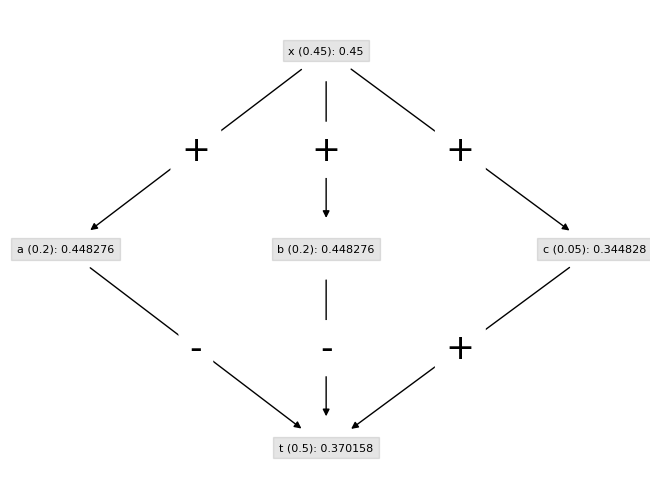

In [9]:
args = ['t', 'a', 'b', 'c', 'x']
initial_strengths = [0.5, 0.2, 0.2, 0.05, 0.45]
atts = [('a', 't'), ('b', 't')]
supps = [('c', 't'), ('x', 'a'), ('x', 'b'), ('x', 'c')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="SquaredDFQuAD_model")

plot_example(qbaf)
visualize(qbaf, with_fs=True, round_to=6)


#### Euler-based Semantics

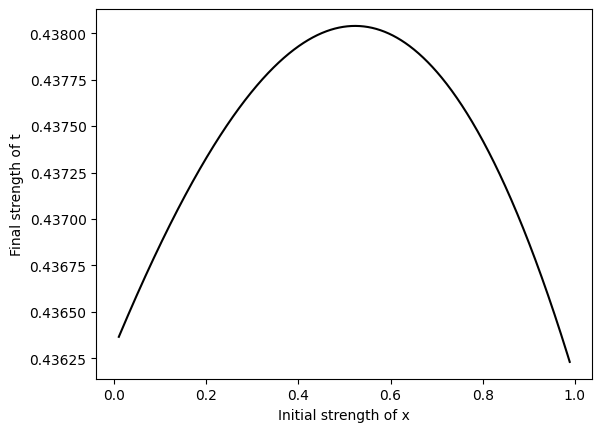

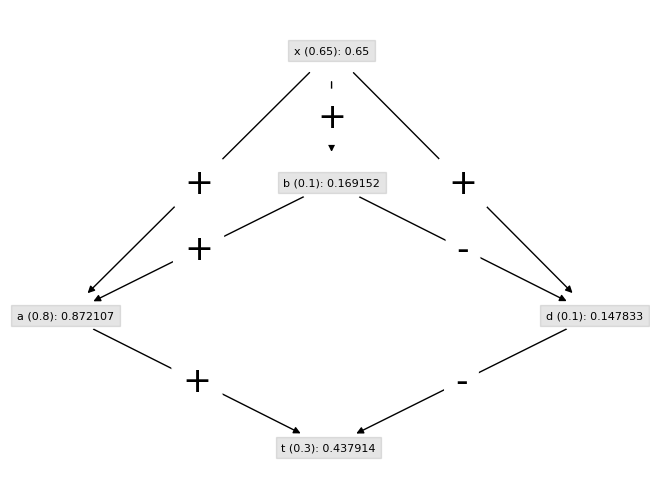

In [10]:

args = ['t', 'a', 'b', 'd', 'x']
initial_strengths = [0.3, 0.8, 0.1, 0.1, 0.65]
atts = [  ('d', 't'), ('b', 'd')]
supps = [('a', 't'), ('b', 'a'),  ('x', 'a'), ('x', 'b'), ('x', 'd')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="EulerBased_model")

plot_example(qbaf)
visualize(qbaf, with_fs=True, round_to=6)

#### Euler-based Top Semantics

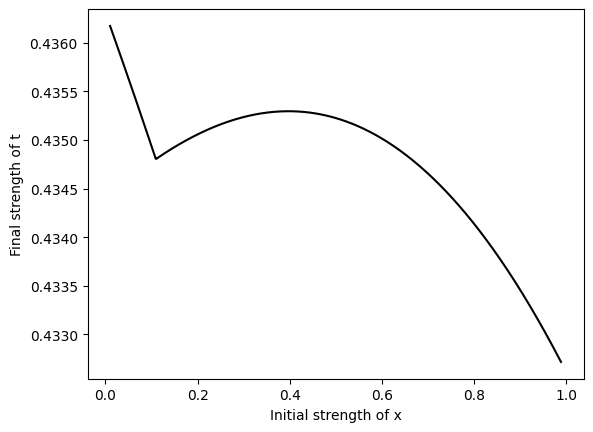

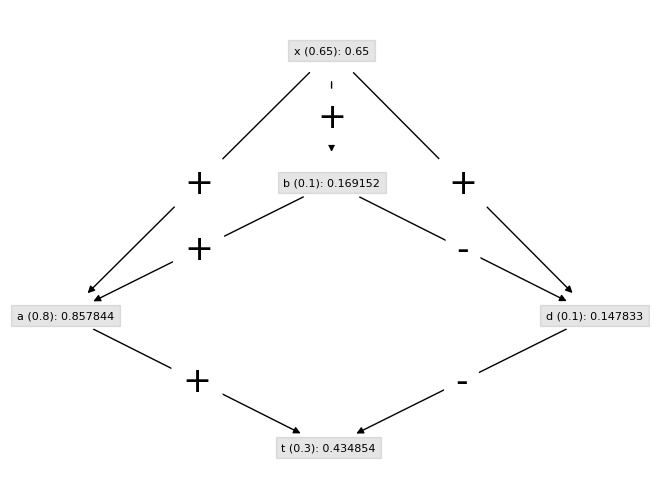

In [11]:
args = ['t', 'a', 'b', 'd', 'x']
initial_strengths = [0.3, 0.8, 0.1, 0.1, 0.65]
atts = [  ('d', 't'), ('b', 'd')]
supps = [('a', 't'), ('b', 'a'),  ('x', 'a'), ('x', 'b'), ('x', 'd')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="EulerBasedTop_model")

plot_example(qbaf)
visualize(qbaf, with_fs=True, round_to=6)

###

### Attack-Only Graphs

Nonmonotonic effects exist in acyclic attack-only graphs, given all five semantics.

#### QE Semantics

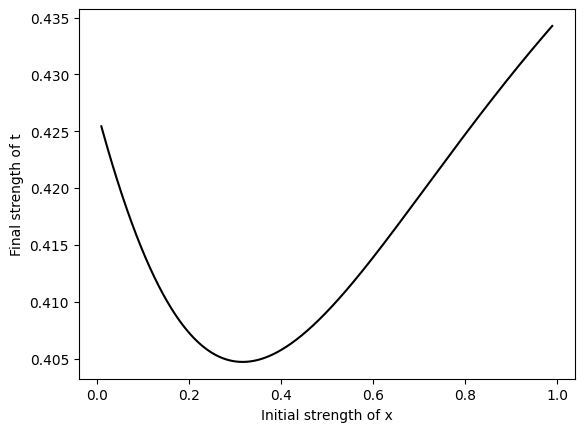

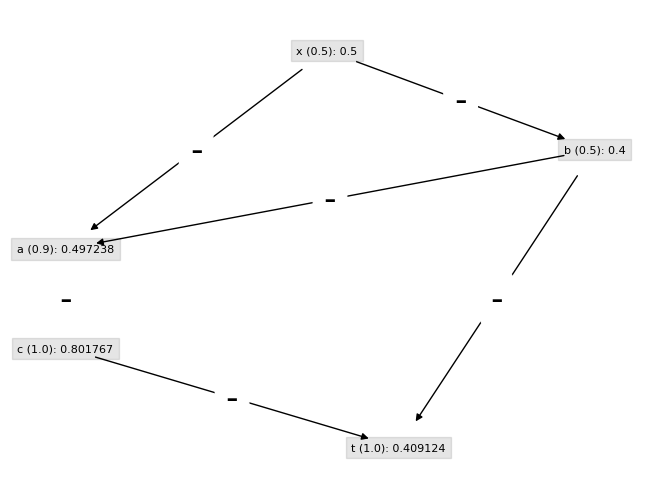

In [12]:
args = ['t', 'a', 'b', 'c', 'x']
initial_strengths = [1, 0.9, 0.5, 1, 0.5]
atts = [('b', 'a'), ('b', 't'), ('x', 'a'),  ('x', 'b'), ('a', 'c'), ('c', 't')]
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")

plot_example(qbaf)
visualize(qbaf, with_fs=True, round_to=6)


#### DFQuAD Semantics

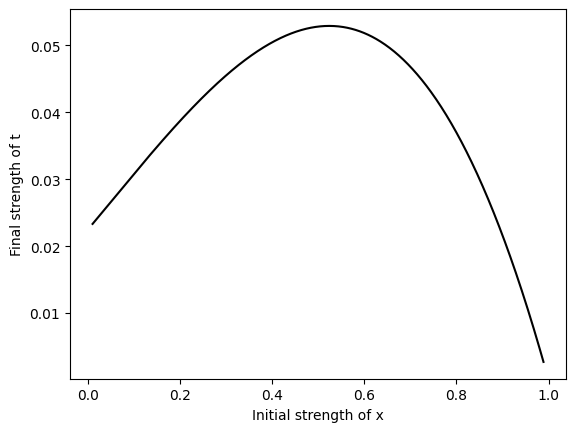

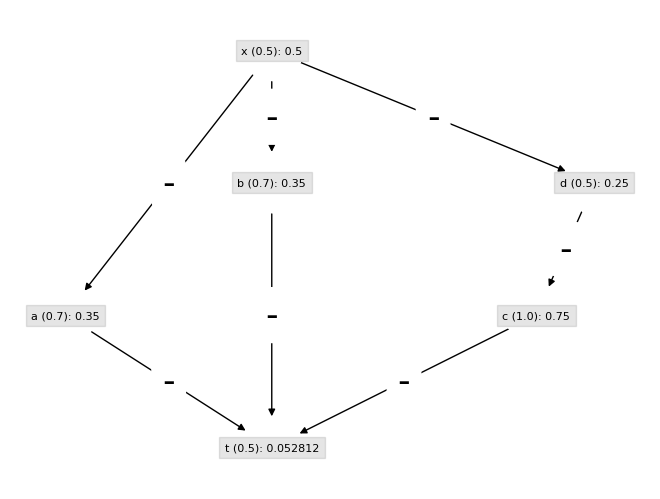

In [13]:
args = ['t', 'a', 'b', 'c', 'd', 'x']
initial_strengths = [0.5, 0.7, 0.7, 1, 0.5, 0.5]
atts = [('a', 't'), ('b', 't'), ('c', 't'), ('x', 'a'), ('x', 'b'), ('x', 'd'), ('d', 'c')]
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

plot_example(qbaf)
visualize(qbaf, with_fs=True, round_to=6)

#### Squared DFQuAD Semantics

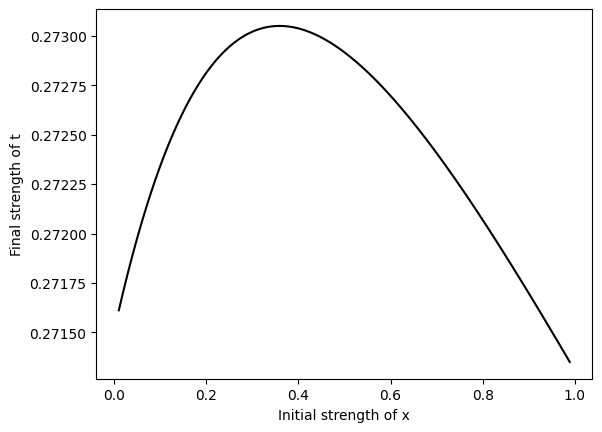

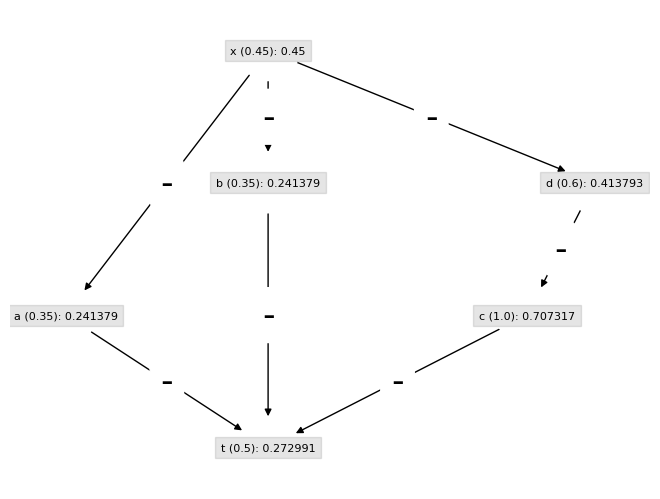

In [14]:
args = ['t', 'a', 'b', 'c', 'd', 'x']
initial_strengths = [0.5, 0.35, 0.35, 1, 0.6, 0.45]
atts = [('a', 't'), ('b', 't'), ('c', 't'), ('x', 'a'), ('x', 'b'), ('x', 'd'), ('d', 'c')]
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="SquaredDFQuAD_model")

plot_example(qbaf)
visualize(qbaf, with_fs=True, round_to=6)

#### Euler-based Semantics

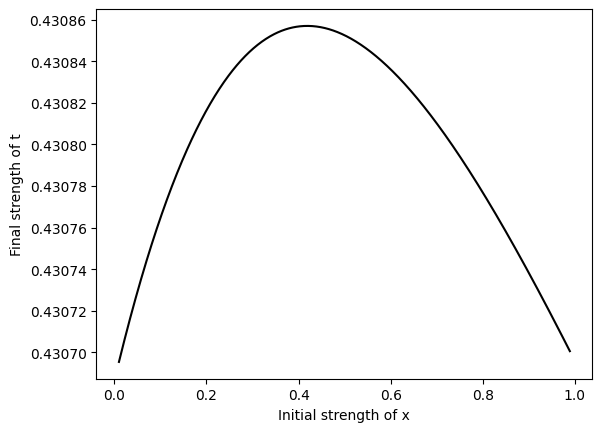

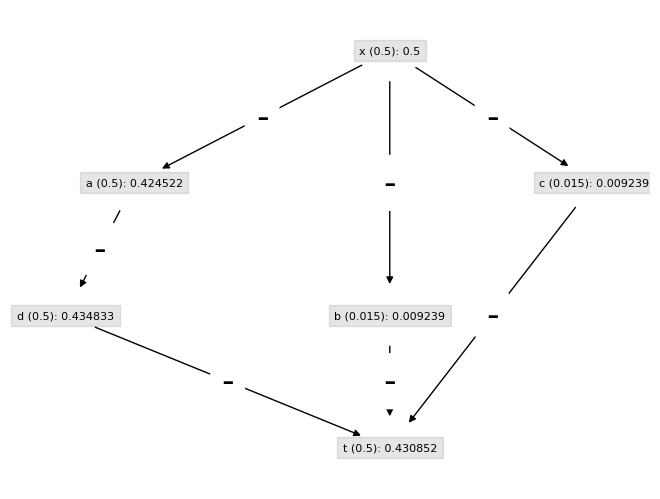

In [15]:
args = ['t', 'a', 'b', 'c', 'd', 'x']
initial_strengths = [0.5, 0.5, 0.015, 0.015, 0.5, 0.5]
atts = [('b', 't'), ('x', 'a'),  ('x', 'b'), ('a', 'd'), ('d', 't'), ('x', 'c'), ('c', 't')]
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="EulerBased_model")

plot_example(qbaf)
visualize(qbaf, with_fs=True, round_to=6)

#### Euler-based Top Semantics

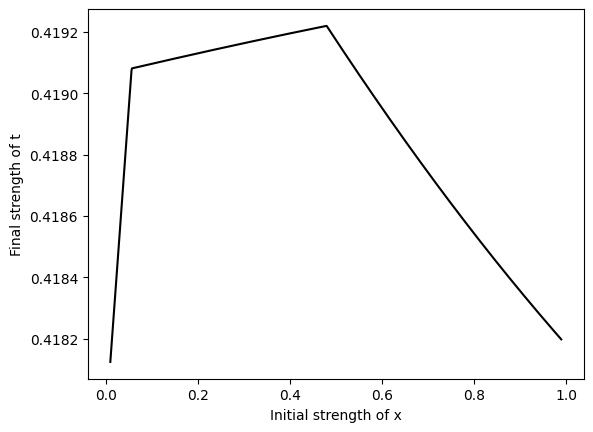

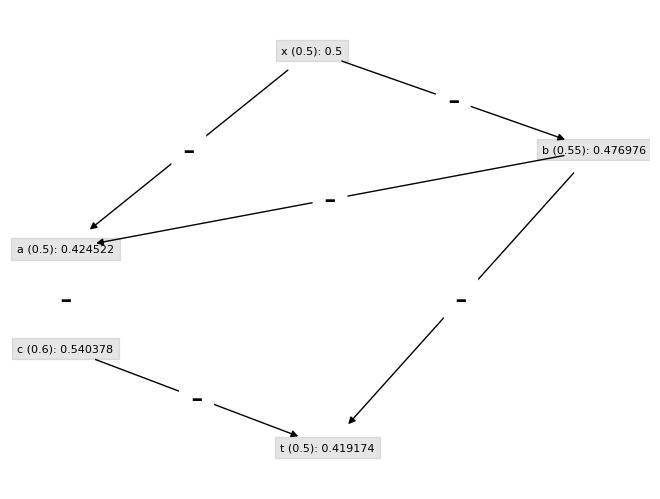

In [16]:
args = ['t', 'a', 'b', 'c', 'x']
initial_strengths = [0.5, 0.5, 0.55, 0.6, 0.5]
atts = [('b', 'a'), ('b', 't'), ('x', 'a'),  ('x', 'b'), ('a', 'c'), ('c', 't')]
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="EulerBasedTop_model")

plot_example(qbaf)
visualize(qbaf, with_fs=True, round_to=6)

## Existence of Pseudo-Nonmonotonic Effects

### Bipolar Graphs
Pseudo-nonmonotonic effects exist in acyclic bipolar graphs given all five semantics.

#### QE Semantics

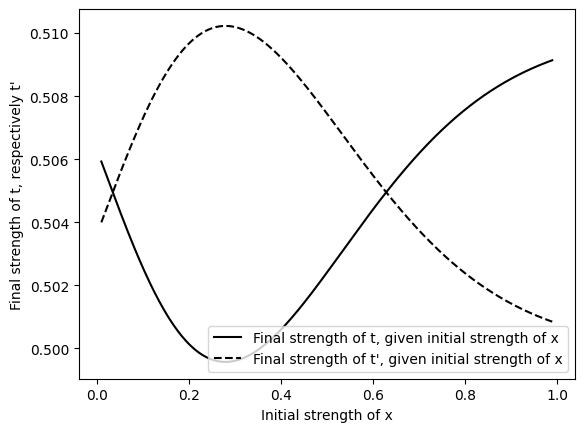

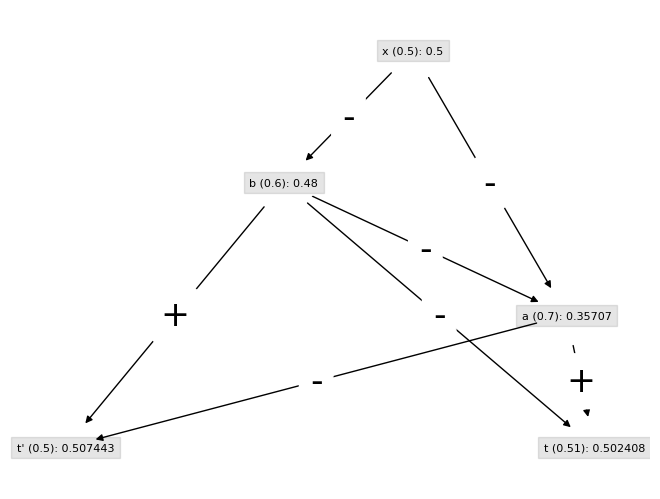

In [17]:
args = ['t', 't\'', 'a', 'b', 'x']
initial_strengths = [0.51, 0.5, 0.7, 0.6, 0.5]
atts = [('b', 'a'), ('b', 't'), ('x', 'a'),  ('x', 'b'), ('a', 't\'')]
supps = [('a', 't'), ('b', 't\'')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### DFQuAD Semantics

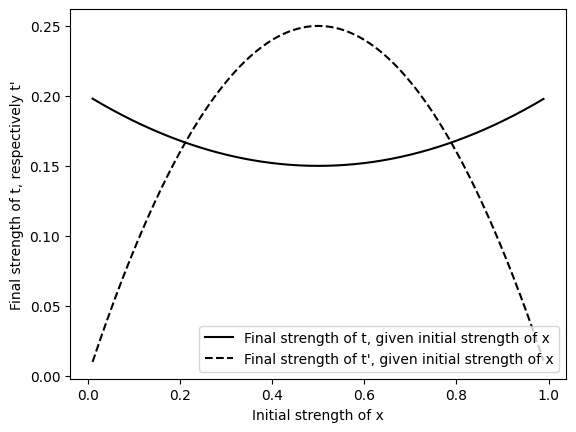

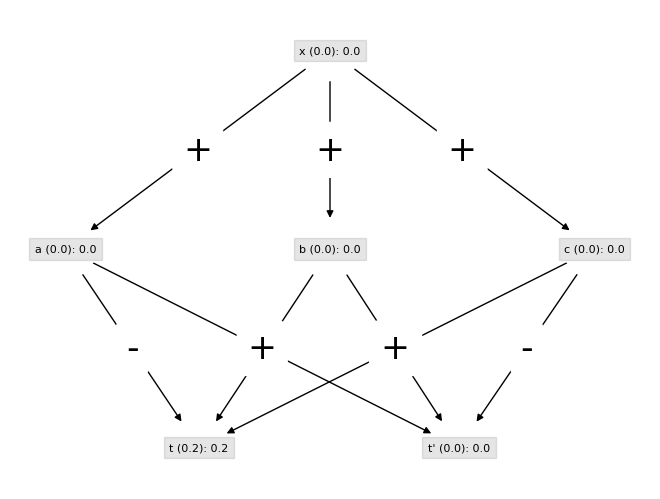

In [18]:
args = ['t', 't\'', 'a', 'b', 'c', 'x']
initial_strengths = [0.2, 0.0, 0.0, 0.0, 0.0, 0.0]
atts = [('a', 't'), ('b', 't'), ('c', 't\'')]
supps = [('c', 't'), ('a', 't\''), ('b', 't\''), ('x', 'c'), ('x', 'a'), ('x', 'b')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### Squared DFQuAD Semantics

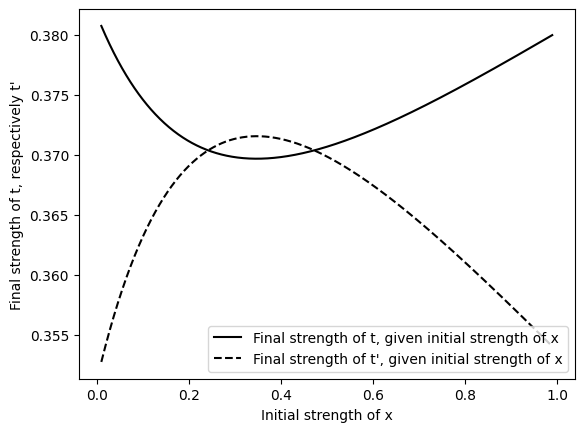

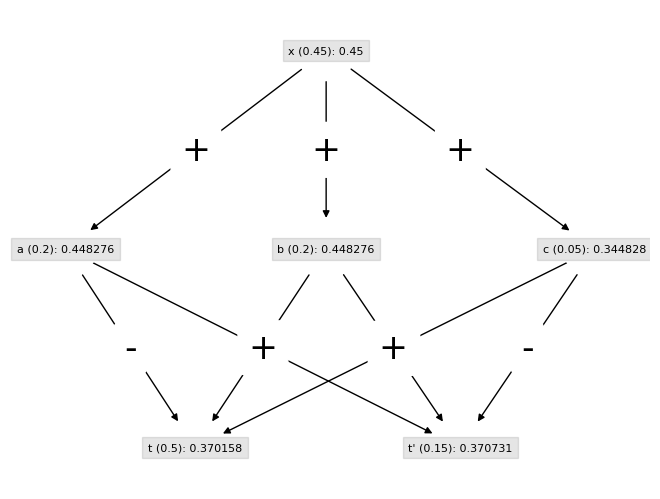

In [19]:
args = ['t', 't\'', 'a', 'b', 'c', 'x']
initial_strengths = [0.5, 0.15, 0.2, 0.2, 0.05, 0.45]
atts = [('a', 't'), ('b', 't'), ('c', 't\'')]
supps = [('c', 't'), ('x', 'a'), ('x', 'b'), ('x', 'c'), ('a', 't\''), ('b', 't\'')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="SquaredDFQuAD_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### Euler-based Semantics

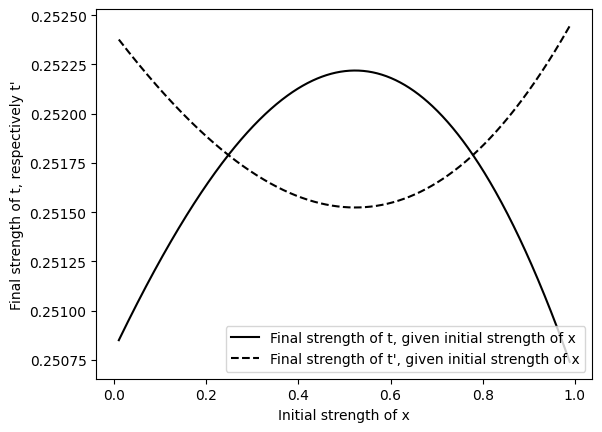

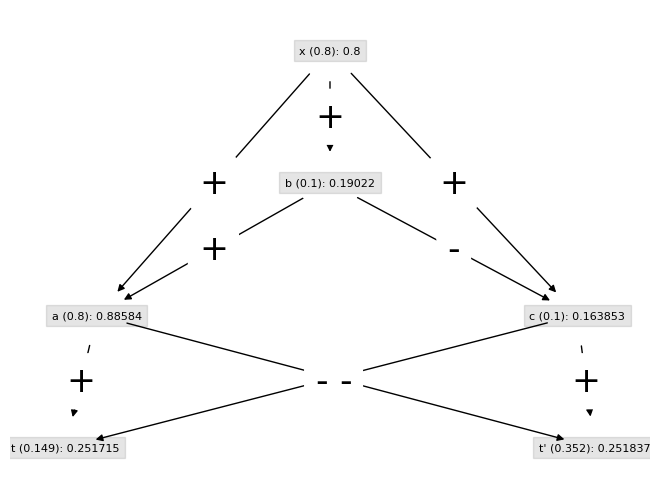

In [20]:
args = ['t', 't\'', 'a', 'b', 'c', 'x']
initial_strengths = [0.149, 0.352, 0.8, 0.1, 0.1, 0.8]
atts = [  ('c', 't'), ('b', 'c'), ('c', 't'), ('a', 't\'')]
supps = [('a', 't'), ('b', 'a'),  ('x', 'a'), ('x', 'b'), ('x', 'c'), ('c', 't\'')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="EulerBased_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### Euler-based Top Semantics

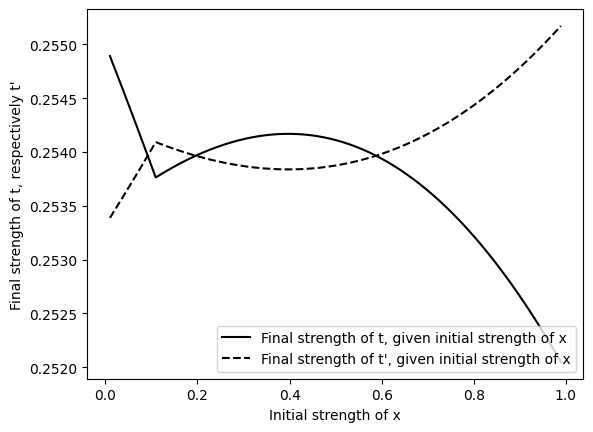

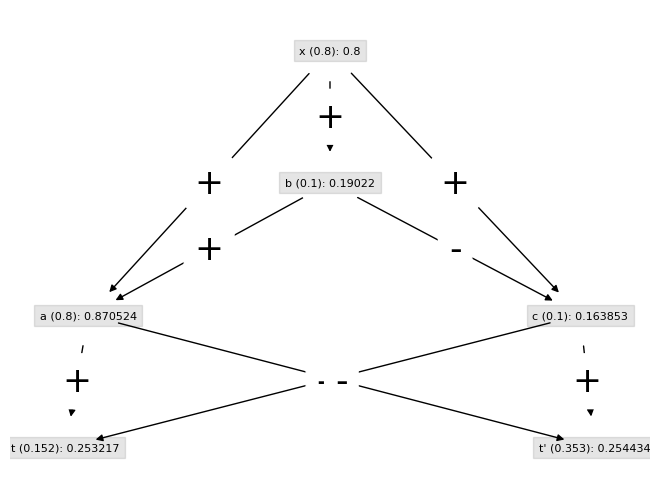

In [21]:
args = ['t', 't\'', 'a', 'b', 'c', 'x']
initial_strengths = [0.152, 0.353, 0.8, 0.1, 0.1, 0.8]
atts = [  ('c', 't'), ('b', 'c'), ('c', 't'), ('a', 't\'')]
supps = [('a', 't'), ('b', 'a'),  ('x', 'a'), ('x', 'b'), ('x', 'c'), ('c', 't\'')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="EulerBasedTop_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

### Attack-Only Graphs
Pseudo-nonmonotonic effects exist in acyclic attack-only graphs, given all five semantics.

#### QE Semantics

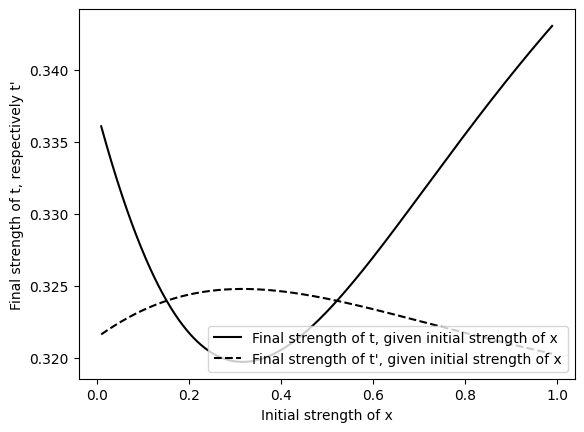

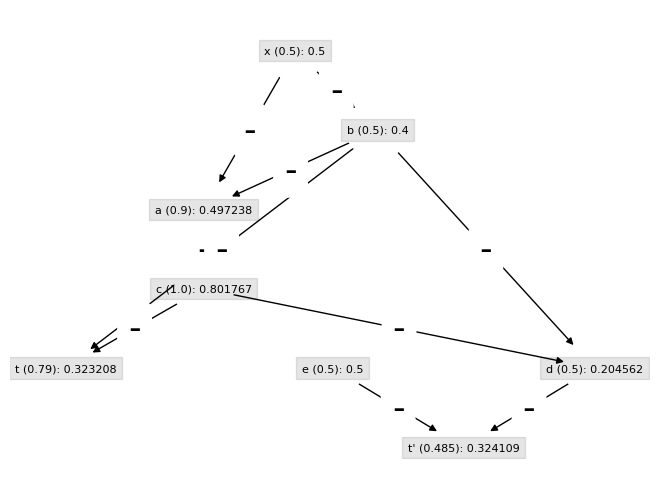

In [22]:
args = ['t', 't\'', 'a', 'b', 'c', 'd', 'e', 'x']
initial_strengths = [0.79,  0.485, 0.9, 0.5, 1, 0.5, 0.5, 0.5]
atts = [('b', 'a'), ('b', 't'), ('x', 'a'),  ('x', 'b'), ('a', 'c'), ('c', 't'), ('d', 't\''), ('e', 't\''), ('c', 'd'), ('b', 'd')]
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)


#### DFQuAD Semantics

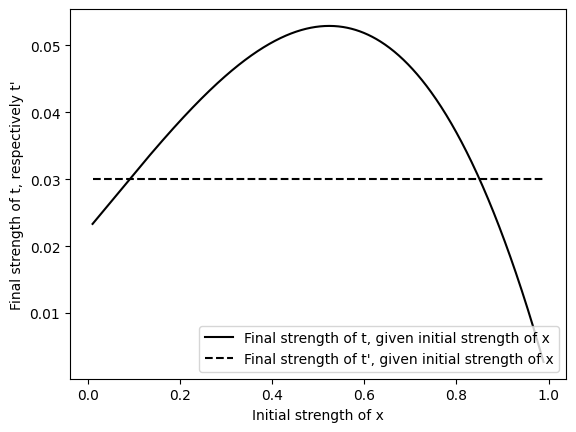

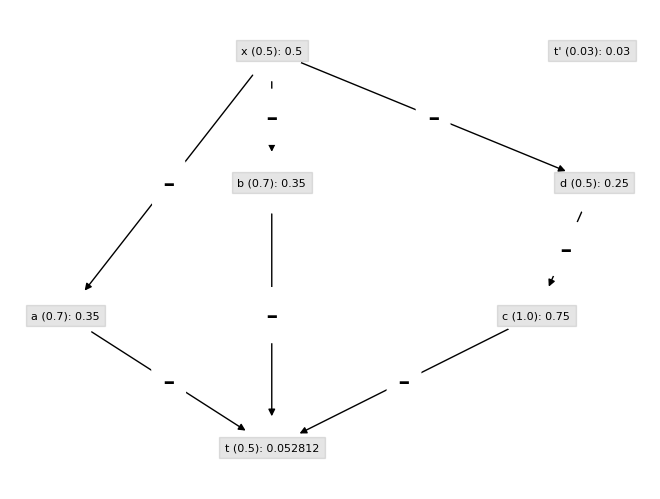

In [23]:
args = ['t', 't\'', 'a', 'b', 'c', 'd', 'x']
initial_strengths = [0.5, 0.03, 0.7, 0.7, 1, 0.5, 0.5]
atts = [('a', 't'), ('b', 't'), ('c', 't'), ('x', 'a'), ('x', 'b'), ('x', 'd'), ('d', 'c')]
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### Squared DFQuAD Semantics

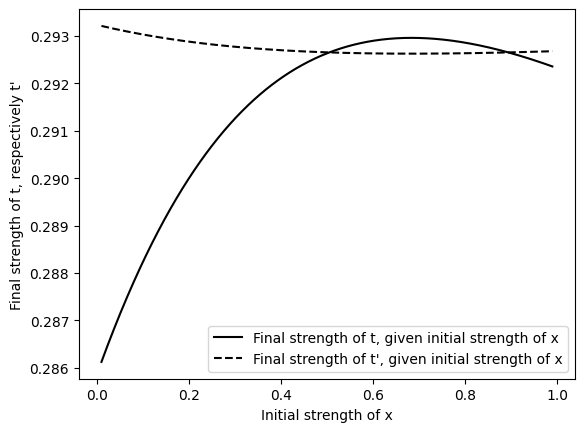

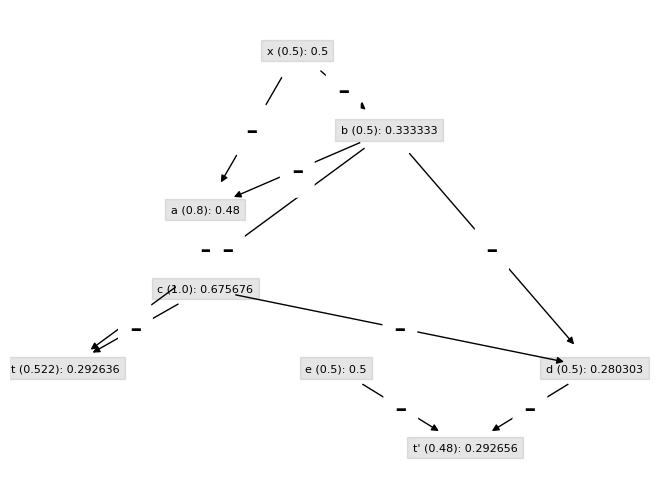

In [24]:
args = ['t', 't\'', 'a', 'b', 'c', 'd', 'e', 'x']
initial_strengths = [0.522, 0.48, 0.8, 0.5, 1, 0.5, 0.5, 0.5]
atts = [('b', 'a'), ('b', 't'), ('x', 'a'),  ('x', 'b'), ('a', 'c'), ('c', 't'), ('d', 't\''), ('e', 't\''), ('c', 'd'), ('b', 'd')]
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="SquaredDFQuAD_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)


#### Euler-based Semantics

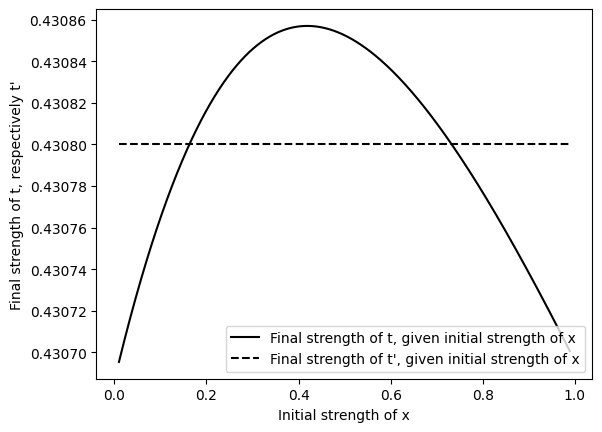

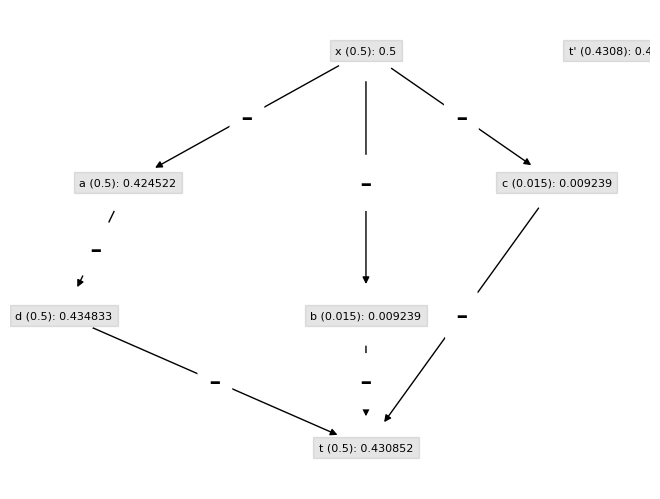

In [25]:
args = ['t', 't\'', 'a', 'b', 'c', 'd', 'x']
initial_strengths = [0.5, 0.4308, 0.5, 0.015, 0.015, 0.5, 0.5]
atts = [('b', 't'), ('x', 'a'),  ('x', 'b'), ('a', 'd'), ('d', 't'), ('x', 'c'), ('c', 't')]
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="EulerBased_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### Euler-based Top Semantics

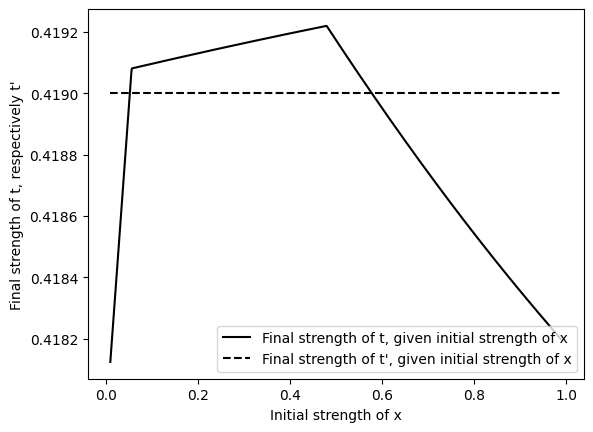

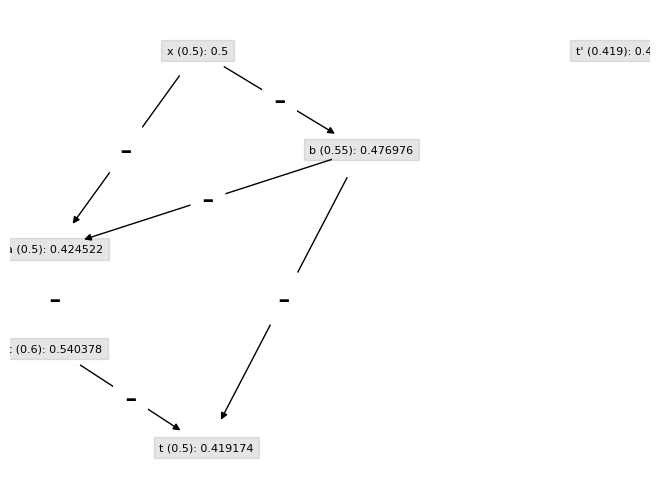

In [26]:
args = ['t', 't\'', 'a', 'b', 'c', 'x']
initial_strengths = [0.5, 0.419, 0.5, 0.55, 0.6, 0.5]
atts = [('b', 'a'), ('b', 't'), ('x', 'a'),  ('x', 'b'), ('a', 'c'), ('c', 't')]
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="EulerBasedTop_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

### Consistent-Polarity Graphs
Pseudo-nonmonotonic effects exist in acyclic consistent-polarity graphs, given all five semantics.

#### QE Semantics

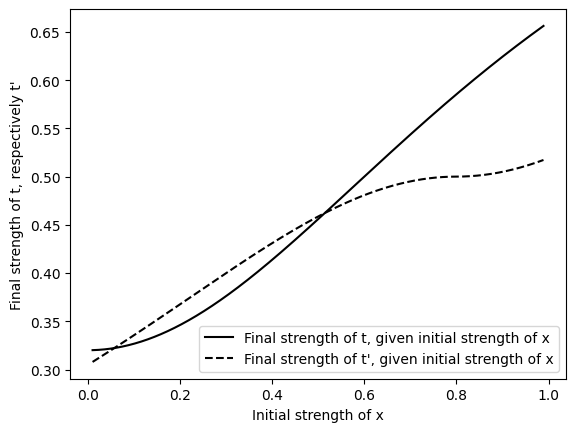

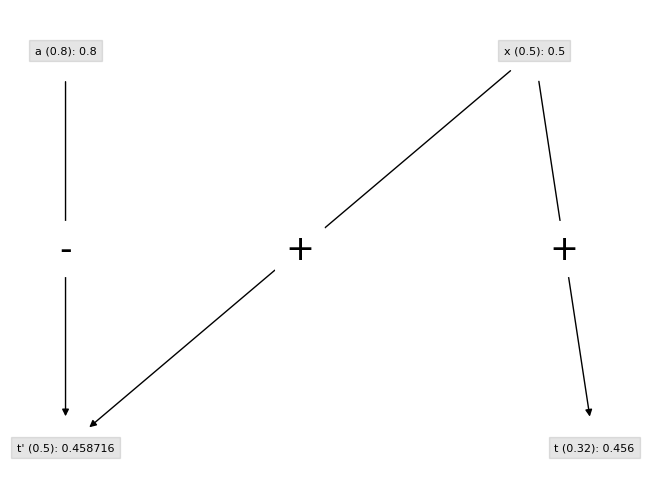

In [27]:
args = ['t', 't\'', 'a', 'x']
initial_strengths = [0.32, 0.5, 0.8, 0.5]
atts = [('a', 't\'')]
supps = [('x', 't'), ('x', 't\'')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### DFQuAD Semantics

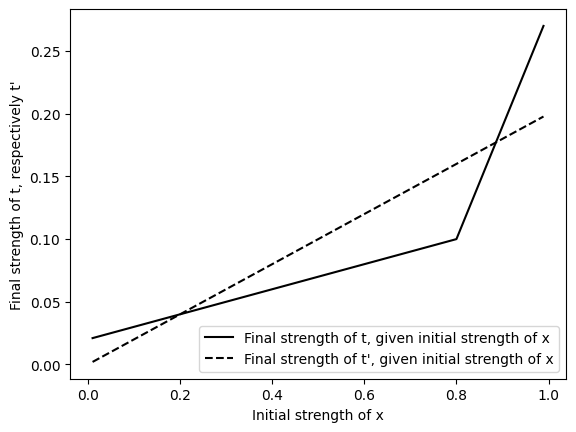

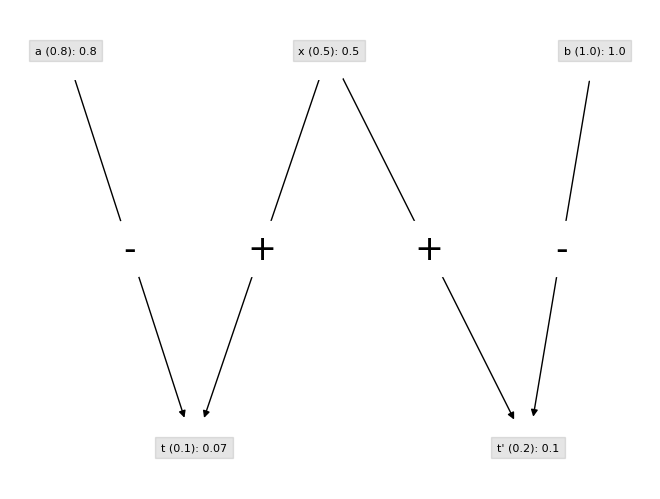

In [28]:
args = ['t', 't\'', 'a', 'b', 'x']
initial_strengths = [0.1, 0.2, 0.8, 1.0, 0.5]
atts = [('a', 't'), ('b', 't\'')]
supps = [('x', 't'), ('x', 't\'')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### Squared DFQuAD Semantics

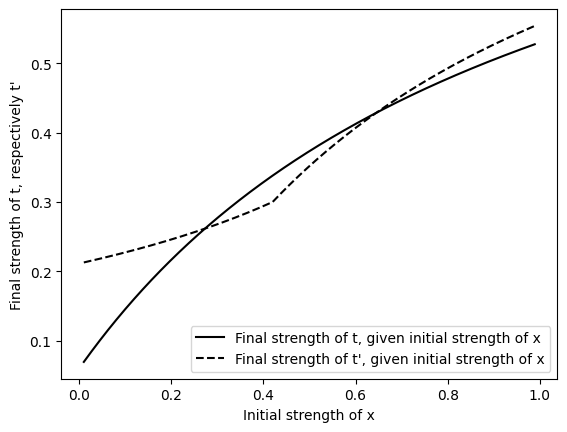

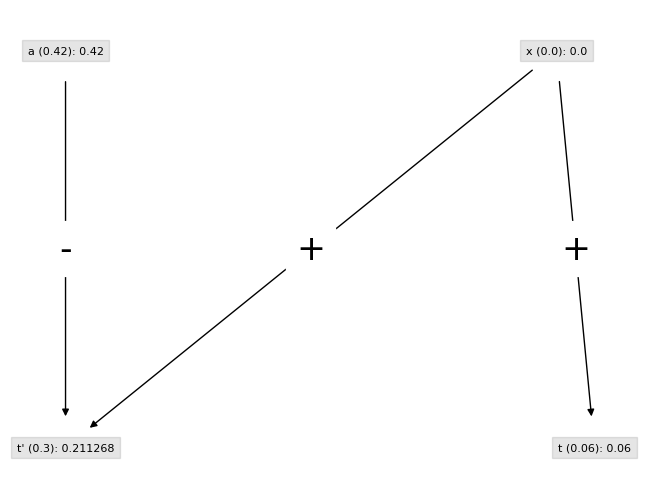

In [29]:
args = ['t', 't\'', 'a', 'x']
initial_strengths = [0.06, 0.3, 0.42, 0.0]
atts = [('a', 't\'')]
supps = [('x', 't'), ('x', 't\'')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="SquaredDFQuAD_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### Euler-based Semantics

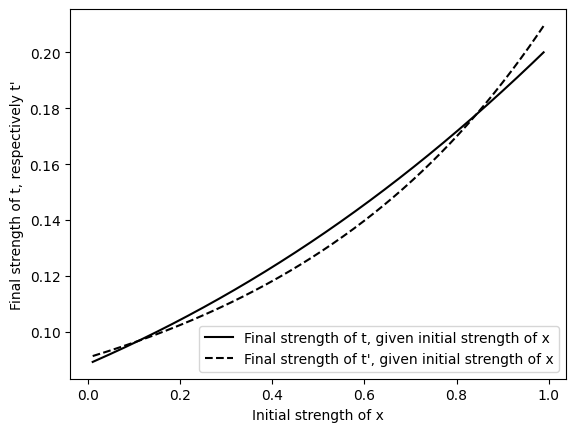

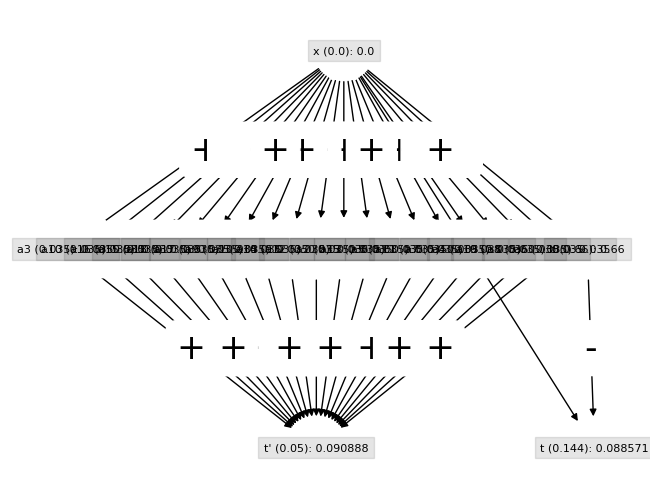

In [30]:
args = ['t', 't\'', 'x', 'b']
initial_strengths = [0.144, 0.05, 0, 0.66]
atts = [('x', 'b'), ('b', 't')]
supps = [('x', 't')]


for i in range(1, 20):
    new_arg = f'a{i}'
    args.append(new_arg)
    initial_strengths.append(0.035)
    supps.append(('x', new_arg))
    supps.append((new_arg, 't\''))

qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="EulerBased_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### Euler-based Top Semantics

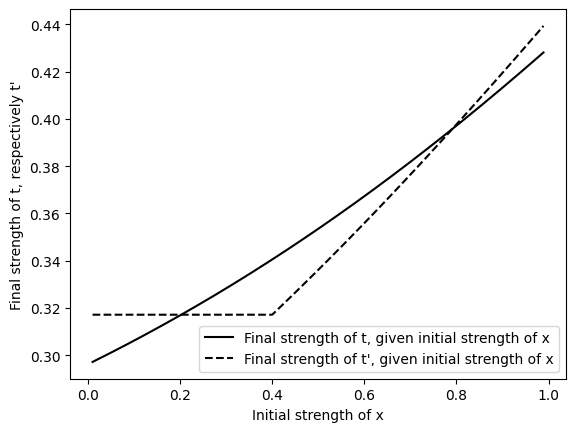

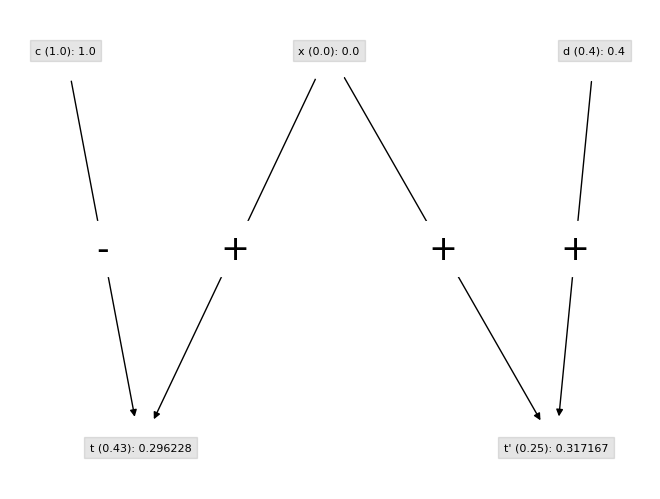

In [31]:
args = ['t', 't\'', 'c', 'd', 'x']
initial_strengths = [0.43, 0.25, 1, 0.4, 0.0]
atts = [('c', 't')]
supps = [('d', 't\''), ('x', 't'), ('x', 't\'')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="EulerBasedTop_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

### Support-Only Graphs
Pseudo-nonmonotonic effects exist in acyclic support-only graphs given all five semantics.
For some semantics (QE, squared DFQuAD, and Euler-based top), counter-examples exist that are multi-trees with topic arguments as root nodes.

#### QE Semantics

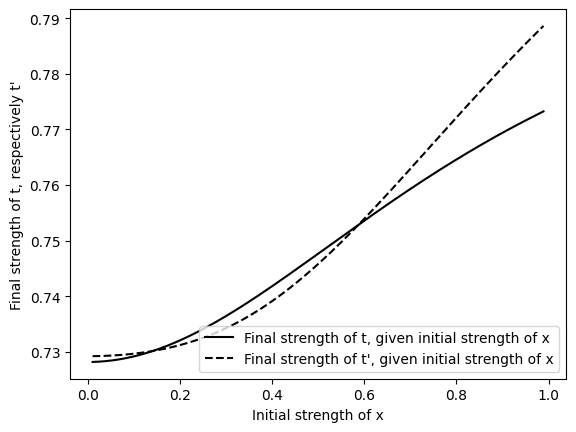

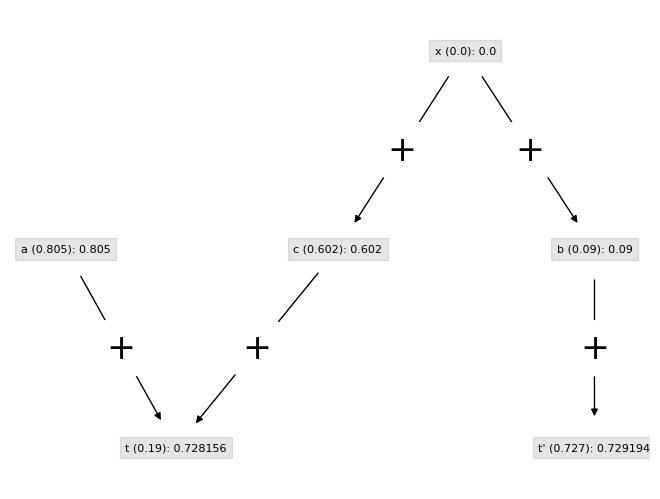

In [32]:
args = ['t', 't\'', 'a', 'b', 'c', 'x']
initial_strengths = [0.19, 0.727, 0.805, 0.09, 0.602, 0]
atts = []
supps = [('a', 't'), ('b', 't\''), ('x', 'c'), ('x', 'b'), ('c', 't')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### DFQuAD Semantics

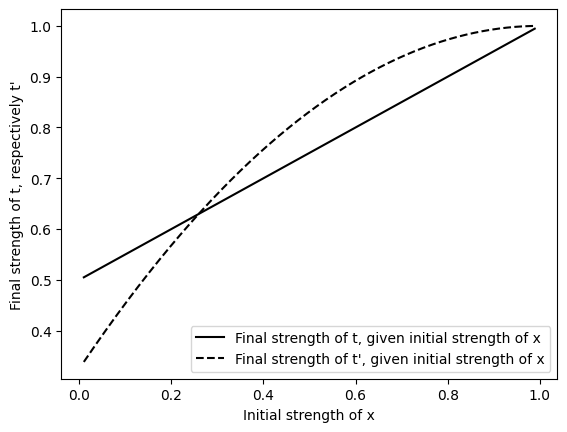

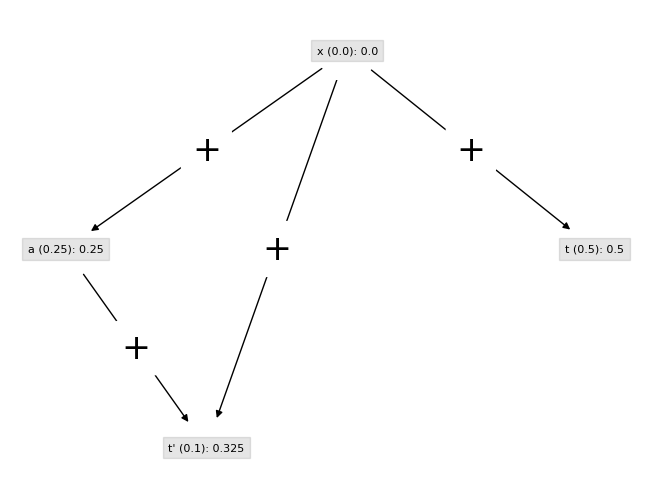

In [33]:
args = ['t', 't\'', 'a', 'x']
initial_strengths = [0.5, 0.1, 0.25, 0]
atts = []
supps = [('a', 't\''), ('x', 't'), ('x', 't\''), ('x', 'a')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### Squared DFQuAD Semantics

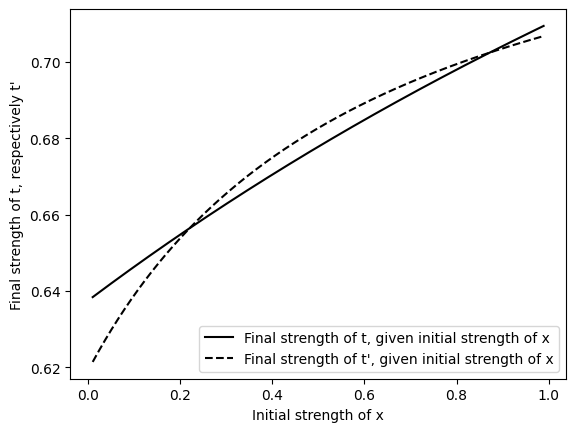

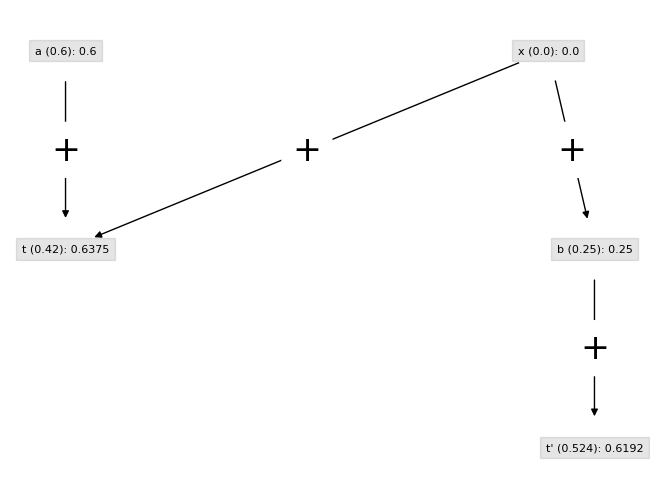

In [34]:
args = ['t', 't\'', 'a', 'b', 'x']
initial_strengths = [0.42, 0.524, 0.6, 0.25, 0]
atts = []
supps = [('a', 't'), ('b', 't\''), ('x', 't'), ('x', 'b')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="SquaredDFQuAD_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### Euler-based Semantics

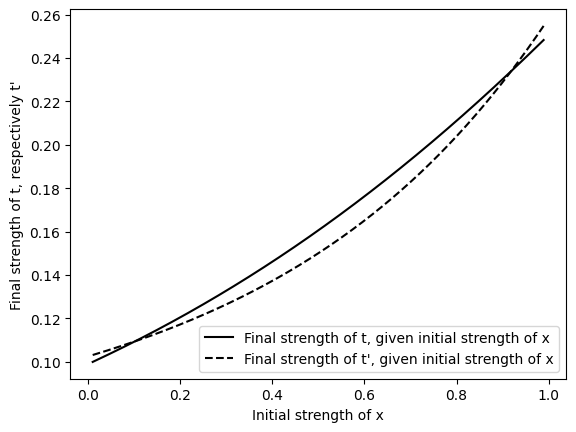

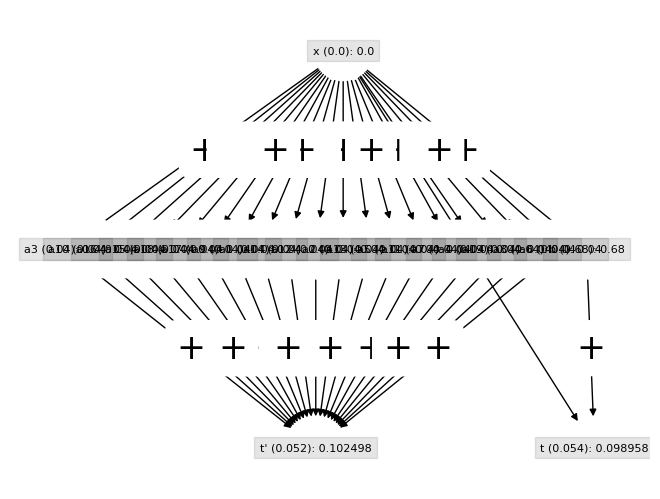

In [35]:
args = ['t', 't\'', 'b', 'x']
initial_strengths = [0.054, 0.052, 0.68, 0]
atts = []
supps = [('x', 't'), ('x', 'b'), ('b', 't')]


for i in range(1, 20):
    new_arg = f'a{i}'
    args.append(new_arg)
    initial_strengths.append(0.04)
    supps.append(('x', new_arg))
    supps.append((new_arg, 't\''))

qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="EulerBased_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)

#### Euler-based Top Semantics

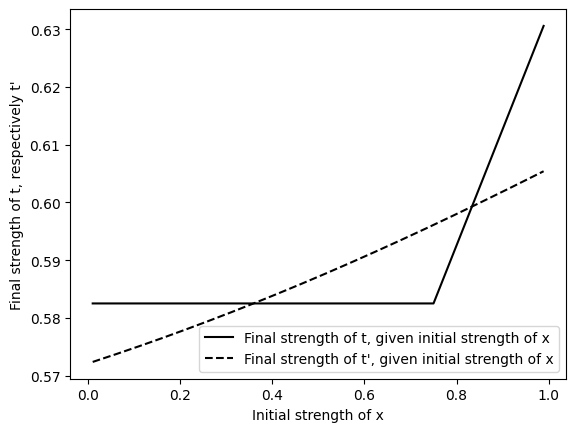

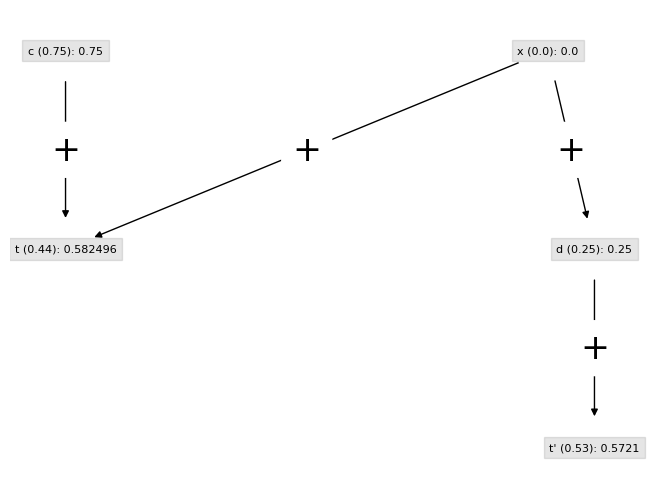

In [36]:
args = ['t', 't\'', 'c', 'd', 'x']
initial_strengths = [0.44, 0.53, 0.75, 0.25, 0]
atts = []
supps = [('c', 't'), ('d', 't\''), ('x', 't'), ('x', 'd')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="EulerBasedTop_model")

plot_example(qbaf, True)
visualize(qbaf, with_fs=True, round_to=6)